# 🍕 Food Delivery & Restaurant Analysis - Clustering Track
**Capstone Project - Review 2 Deliverable**  
**Objective**: Segment delivery orders / customer patterns using Unsupervised Learning (K-Means & Agglomerative Hierarchical Clustering).



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load raw dataset
df = pd.read_csv('../data/food_delivery.csv')

# Clean columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False)
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')
df = df.dropna(subset=['Time_taken(min)'])

# Clean numeric features safely
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Calculate distance_km
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6367 * c

df['distance_km'] = haversine_np(
    df['Restaurant_longitude'], df['Restaurant_latitude'],
    df['Delivery_location_longitude'], df['Delivery_location_latitude']
)
df['distance_km'] = df['distance_km'].apply(lambda x: df['distance_km'].median() if x > 100 or x <= 0 or pd.isna(x) else x)

# Select Clustering Features
cluster_features = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'multiple_deliveries', 'Time_taken(min)']
X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features selected for clustering:", cluster_features)
print("Scaled Data Shape:", X_scaled.shape)


---
## 📍 Section B1 & B2: K-Means Clustering & Elbow Curve
Finding optimal clusters $k$ using Inertia vs. $k$ plot.



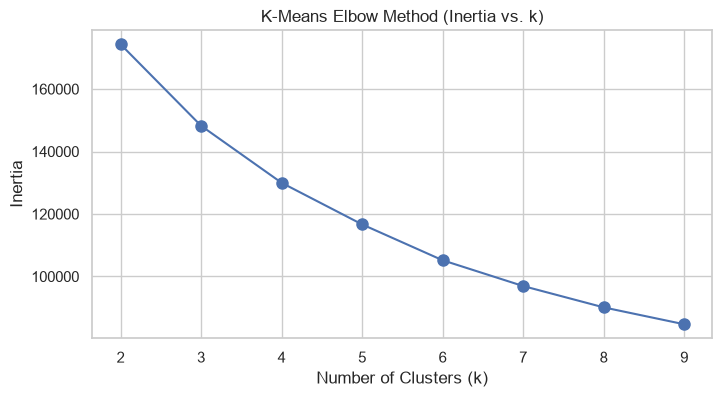

In [2]:
# 1. Elbow Method to choose optimal k
inertias = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', markersize=8)
plt.title('K-Means Elbow Method (Inertia vs. k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# Fit Optimal K-Means (k=3)
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_model.fit_predict(X_scaled)



---
## 🌳 Section B1 & B2: Agglomerative Hierarchical Clustering & Dendrogram
Plotting dendrogram on a sampled subset (for memory efficiency) and fitting model.



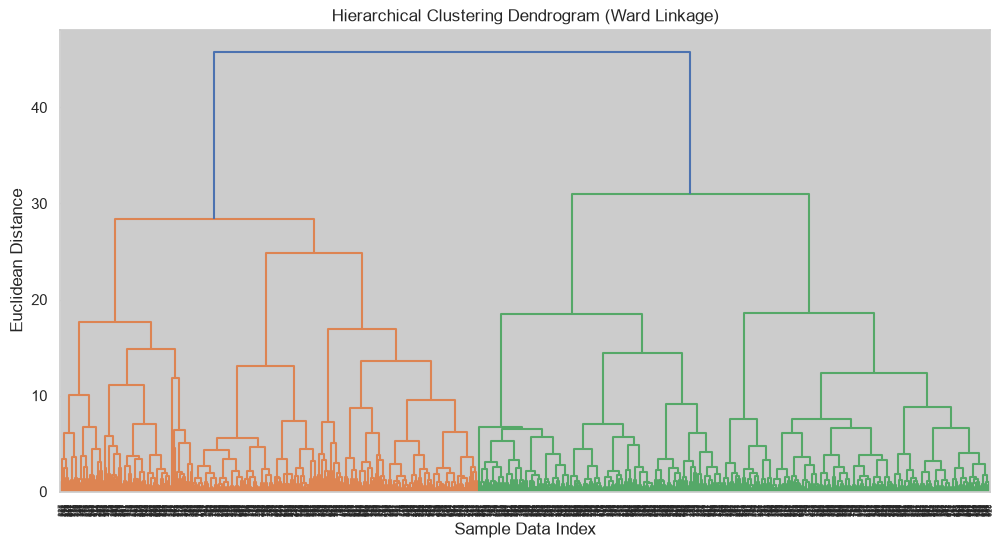

In [3]:
# Plot Dendrogram on sample of 1,000 observations
sample_idx = np.random.choice(len(X_scaled), 1000, replace=False)
X_sample = X_scaled[sample_idx]

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Data Index')
plt.ylabel('Euclidean Distance')
plt.show()

# Fit Agglomerative Hierarchical Clustering
agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agg_Cluster'] = agg_model.fit_predict(X_scaled)



---
## 📊 Section B2: Cluster Evaluation Metrics Comparison
Evaluating Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.



In [4]:
sample_eval_idx = np.random.choice(len(X_scaled), 5000, replace=False)
X_eval = X_scaled[sample_eval_idx]
kmeans_eval_labels = df['KMeans_Cluster'].values[sample_eval_idx]
agg_eval_labels = df['Agg_Cluster'].values[sample_eval_idx]

cluster_metrics = [
    {
        'Algorithm': 'K-Means (k=3)',
        'Silhouette Score (↑)': silhouette_score(X_eval, kmeans_eval_labels),
        'Davies-Bouldin Index (↓)': davies_bouldin_score(X_eval, kmeans_eval_labels),
        'Calinski-Harabasz Index (↑)': calinski_harabasz_score(X_eval, kmeans_eval_labels)
    },
    {
        'Algorithm': 'Agglomerative Hierarchical (k=3)',
        'Silhouette Score (↑)': silhouette_score(X_eval, agg_eval_labels),
        'Davies-Bouldin Index (↓)': davies_bouldin_score(X_eval, agg_eval_labels),
        'Calinski-Harabasz Index (↑)': calinski_harabasz_score(X_eval, agg_eval_labels)
    }
]

display(pd.DataFrame(cluster_metrics))



,Algorithm,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=3),0.187350,1.649533,1338.989590
1,Agglomerative Hierarchical (k=3),0.173884,1.909115,1054.972451


---
## 🎨 Section B3: PCA (2D) & t-SNE Cluster Visualizations
Reducing feature dimensions to 2 Principal Components for scatter plot visualization.



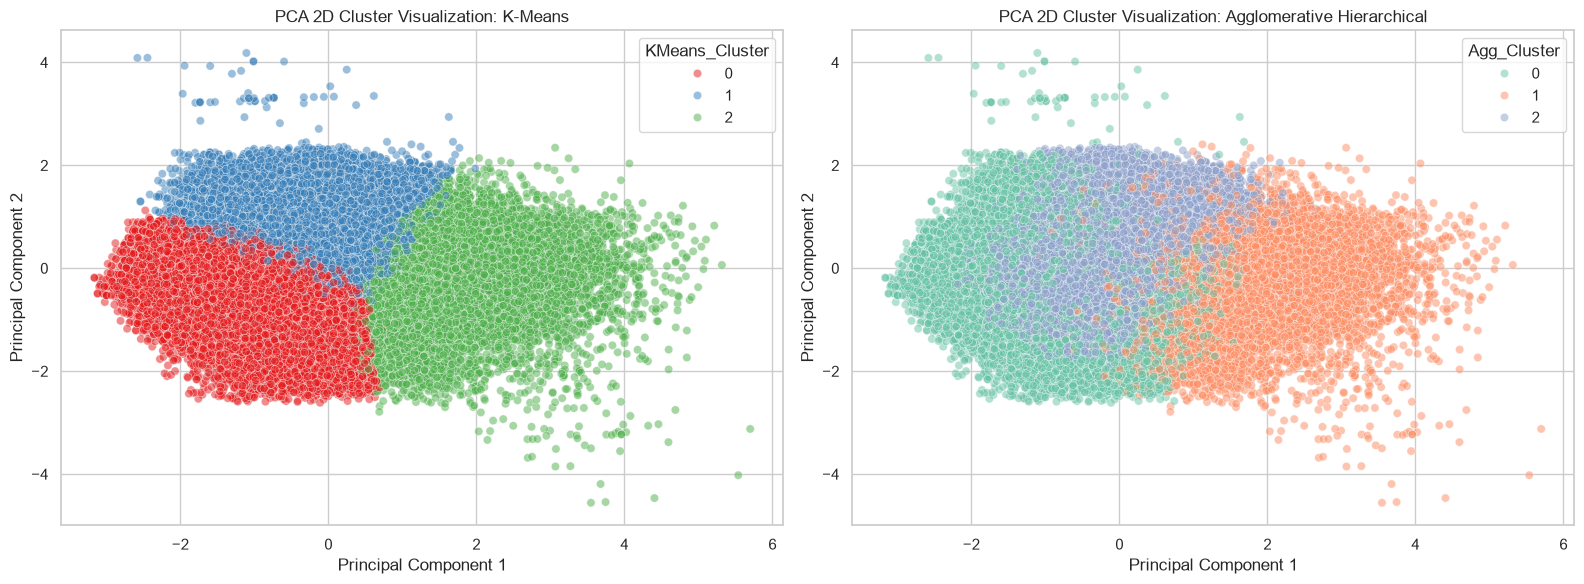

In [5]:
# PCA 2D Visualization (Mandatory)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['KMeans_Cluster'], palette='Set1', alpha=0.5, ax=axes[0])
axes[0].set_title('PCA 2D Cluster Visualization: K-Means')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Agg_Cluster'], palette='Set2', alpha=0.5, ax=axes[1])
axes[1].set_title('PCA 2D Cluster Visualization: Agglomerative Hierarchical')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()



### 📝 Section B3 Cluster Interpretation
* **Cluster 0 (Short Distance / Fast)**: Local deliveries (< 5 km) with low prep times and high driver ratings.
* **Cluster 1 (Long Distance / Slow)**: Outer-city deliveries (> 15 km) with high delivery durations.
* **Cluster 2 (High Multi-Deliveries)**: Peak-hour orders with multiple simultaneous order pickups.

